In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import glob
import cmocean as cmo
import seawater as sw
import sys
import tkinter
from tkinter import filedialog

sys.path.append('../')
import src.data.export_log_data as efuncs
import src.data.read_functions as rfuncs

## SELECT THE INPUT DIRECTORY (SELECT THE FOLDER ENTITLED 'campaignxxx')
inputpath = filedialog.askdirectory()
logdir=os.path.join(inputpath,'files','log')

## SELECT THE OUTPUT DIRECTORY
savedir=os.path.join(inputpath,'files','processed-log-data')
os.makedirs(savedir, exist_ok=True) 
print('Data are saved at '+savedir)

## Unzip all the files (if not unzipped already)
## ALL DATA
files=glob.glob(logdir+'/*xml*')# list files
if files:
# determine if files are zipped. If yes, unzip, if no, continue
    allfiles=os.path.join(logdir,'*.xml.gz')    
    import gzip, shutil
    flelist=glob.glob(allfiles)
    for i in flelist:
        xfle=os.path.splitext(i)[0]
        if not os.path.isfile(xfle):
            with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)


## create null values for datasets, so we can check for existence later
ctdf=pd.DataFrame()
sbpdf=pd.DataFrame()
gpdf=pd.DataFrame()
nvdf=pd.DataFrame()
aandf=pd.DataFrame()               
ecopuck=pd.DataFrame()

C:\Users\Marphys\AppData\Local\Temp\ipykernel_10144\3871450473.py:6: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


Data are saved at C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-CAPEBOWYER\files\processed-log-data


In [2]:
##missionmanager
files=glob.glob(logdir+'/*missionmanager*')
if files: 
    # read nav data and convert to .csv format, output to data/nav-files/
    mmdf=rfuncs.readmmlog(logdir,savedir)

### Autopilot
files=glob.glob(logdir+'/*autopilot*')
if files: 
    # read nav data and convert to .csv format, output to data/nav-files/
    apdf=rfuncs.readautolog(logdir,savedir)

### CTD data

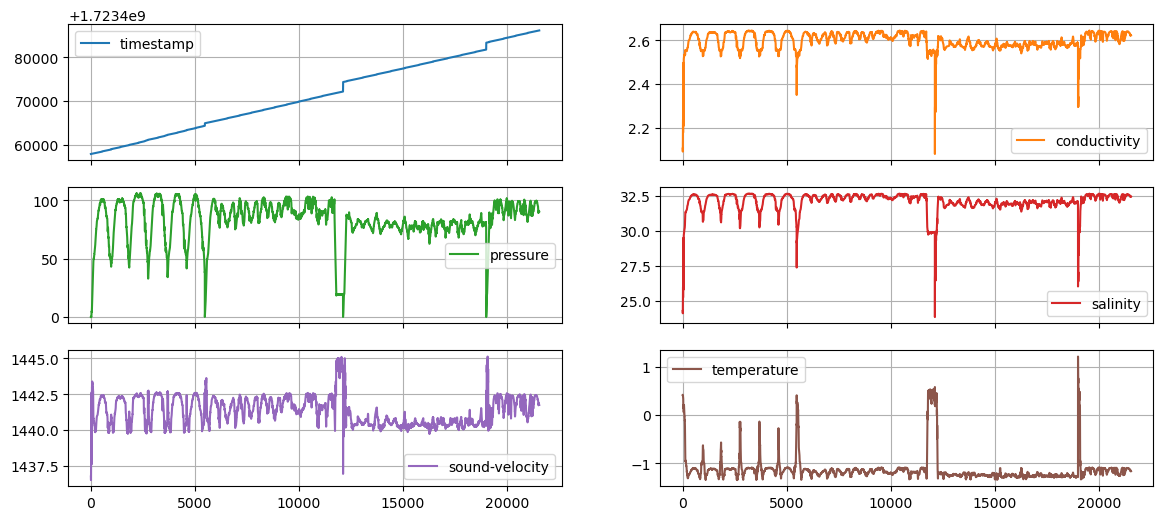

In [3]:
files=glob.glob(logdir+'/*ctd*')
if files:
# read CTD data and convert to .csv format, output to data/ctd-files/
    ctdf=rfuncs.readctdlog(logdir,savedir)
    ctdf.plot(subplots=True,
              layout=(3,2),
              figsize=[14,6],
              grid=True)

## SBP data

In [4]:
files=glob.glob(logdir+'/*sbp*')
if files:
    # read SBP data and convert to .csv format, output to data/sbp-files/
    sbpdf=rfuncs.readsbplog(logdir,savedir)

## GPS data

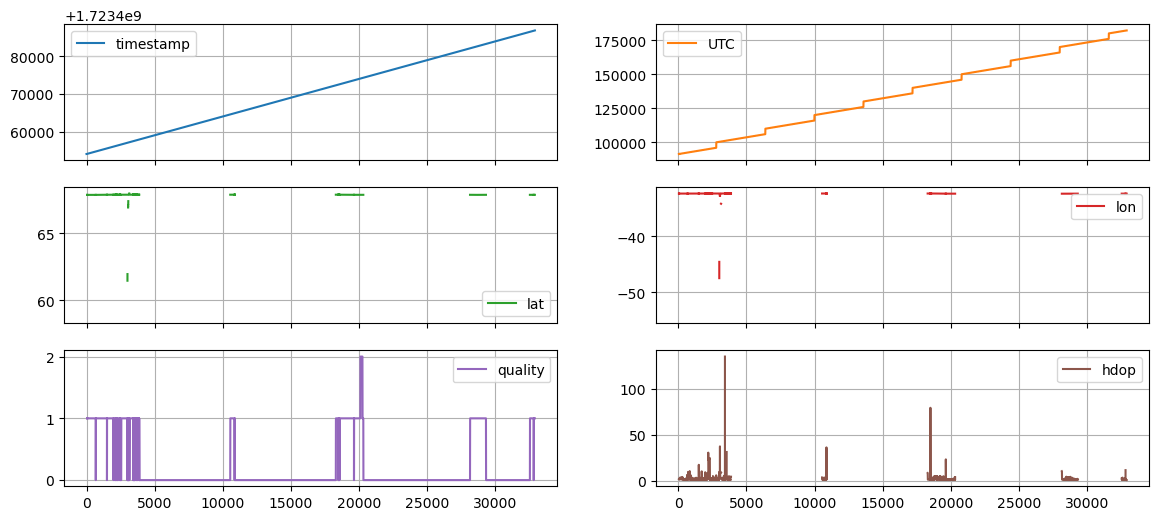

In [5]:
files=glob.glob(logdir+'/*gps*')
if files:    
    # read GPS data and convert to .csv format, output to data/gps-files/
    gpdf=rfuncs.readgpslog(logdir,savedir)
    gpdf=gpdf.drop(columns=[
     'build-number',
     'build-tag',
     'log-level',
     'rate',
     'sbf-remote-com-port',
     'sbf-local-com-port',
     'vsp-local-com-port',
     'corrections-local-com-port',
     'vsp-local-tcp-port',
     'corrections-local-udp-port',
     'vsp-enabled',
     'corrections-enabled',
     'sbf-enabled',
     'sbf-unicast-enabled',
     'sbf-unicast-port',
     'sbf-unicast-interface',
     'log-nmea',
     'log-messages',
     'multicast-receive-enabled',
     'multicast-receive-port',
     'multicast-receive-addr',
     'multicast-receive-interface',
     'messages-received',
     'raw-logged-bytes',
     'received-telnet-bytes',
     'sent-corr-bytes',
     'sent-corr-packets',
     'sent-telnet-bytes',
     'time-since-gga',
     'time-since-sent',
     'diff-age',
     'sats',
     'stnRef',
     'cogt',
     'lat-dev',
     'lon-dev',
     'sogk',
     'sogm'])
    gpdf.head()
    gpdf.plot(subplots=True,
          layout=(3,2),
          figsize=[14,6],
          grid=True)

In [ ]:
files=glob.glob(logdir+'/*nav*')
if files: 
    # read nav data and convert to .csv format, output to data/nav-files/
    nvdf=rfuncs.readnavlog(logdir,savedir)
    # drop unwanted variables form nav data
    nvdf=nvdf.drop(columns=[
         'magnetic-deviation',
         'pressure-warnings',
         'lat-lon-precision',
         'average-water-density',
         'sound-velocity',
         'center-actuators-on-idle',
         'dead-reckoning-orientation',
         'dead-reckoning-velocity',
         'orientation',
         'position',
         'variance',
         'velocity'])

    # rename duplicat variables (t,s, sv, from control module?
    nvdf=nvdf.rename(columns={"time": "time-nav",
                              "salinity": "salinity-nav",
                              "temperature": "temperature-nav",
                              "sound-velocity": "sound-velocity-nav"})
    nvdf.plot(subplots=True, 
               layout=(6,4),
               figsize=[14,6],
               grid=True)    

C:\Users\Marphys\GaviaSciTools\notebooks\..\src\data\read_functions.py:311: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  nvdf[col]=pd.to_numeric(nvdf[col],errors='ignore',downcast='float')
C:\Users\Marphys\GaviaSciTools\notebooks\..\src\data\read_functions.py:311: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  nvdf[col]=pd.to_numeric(nvdf[col],errors='ignore',downcast='float')
C:\Users\Marphys\GaviaSciTools\notebooks\..\src\data\read_functions.py:311: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  nvdf[col]=pd.to_numeric(nvdf[col],errors='ignore',downcast='float')
C:\Users\Marphys\GaviaSciTools\notebooks\..\src\data\read_functions.py:311: Fut

## Aanderra Optopde data

In [ ]:
files=glob.glob(logdir+'/*aanderaa*')
if files: 
    # read aanderaa data and convert to .csv format, output to data/aanderaa-files/
    aandf=rfuncs.readaandlog(logdir,savedir)
    aandf.plot(subplots=True, 
               layout=(4,4),
               figsize=[14,6],
               grid=True)

## ecopuck data

Chlorophyll Scale Factor

CHLDarkCounts=50

CHLScaleFactor=0.0121

CHLMaxOut=4130

CHLRes=1

CHL = CHLScaleFactor x (ecopuck.[chl-raw] - CHLDarkCounts)

Nephelometric Turbidity Unit

NTUDarkCounts=51

NTUSolutionValue=1784

NTUScaleFactor=0.0249

MaxOut=4130

Res=1

In [ ]:
files=glob.glob(logdir+'/*ecopuck*')
if files: 
    # read aanderaa data and convert to .csv format, output to data/aanderaa-files/
    ecopuck=rfuncs.readecolog(logdir,savedir)

# Chlorophyll Scale Factor
CHLDarkCounts=50
CHLScaleFactor=0.0121
CHLMaxOut=4130
CHLRes=1
CHL = CHLScaleFactor*(ecopuck["chl-raw"]-CHLDarkCounts)

# Nephelometric Turbidity Unit
NTUDarkCounts=51
NTUSolutionValue=1784
NTUScaleFactor=0.0249
MaxOut=4130
Res=1
NTU = NTUScaleFactor*(ecopuck["ntu-raw"]-NTUDarkCounts)

# Adding a new column chl-corrected with values
ecopuck['chl-corrected']=CHL.values
ecopuck['ntu-corrected']=NTU.values

ecopuck.plot(subplots=True, 
             layout=(3,3),
             figsize=[14,6],
             grid=True)


In [ ]:
# create merged file
## always gps and nav log to mege first to new df
# round timestamp to o decimal places ready for merging
nvdf=nvdf.round({'timestamp': 0})
gpdf=gpdf.round({'timestamp': 0})
gpdf=gpdf.rename(columns={"time": "time-gps"})

# Mmerge nav data and gps
auvmerge=pd.merge(nvdf, gpdf,how='outer',on='timestamp')

# ctd
if not ctdf.empty:
    ctdf=ctdf.round({'timestamp': 0})
    ctdf=ctdf.rename(columns={"time": "time-ctd"})
    auvmerge=pd.merge(auvmerge, ctdf,how='outer',on='timestamp')

# aandera 
if not aandf.empty:
    aandf=aandf.round({'timestamp': 0})
    aandf=aandf.rename(columns={"time": "time-aand"})
    auvmerge=pd.merge(auvmerge, aandf,how='outer',on='timestamp')

# ecopuck 
if not ecopuck.empty:
    ecopuck=ecopuck.round({'timestamp': 0})
    ecopuck=ecopuck.rename(columns={"time": "time-eco"})
    auvmerge=pd.merge(auvmerge, ecopuck,how='outer',on='timestamp')

# sbp 
if not sbpdf.empty:
    print('to be done later, when we have some data')          

auvmerge.to_csv(os.path.join(savedir,'auvdata.csv')) 

In [ ]:
# ## SEANAV data
# files=glob.glob(logdir+'/*seanav*')# list files
# if files:
# # determine if files are zipped. If yes, unzip, if no, continue
#     seanavfiles=os.path.join(logdir,'*seanav*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(seanavfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

# ## CAPTAIN data
# files=glob.glob(logdir+'/*captain*')# list files
# if files:
# # determine if files are zipped. If yes, unzip, if no, continue
#     seanavfiles=os.path.join(logdir,'*captain*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(seanavfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)
                
# ## autopilot data
# files=glob.glob(logdir+'/*autopilot*')# list files
# if files:
# # determine if files are zipped. If yes, unzip, if no, continue
#     autopilotfiles=os.path.join(logdir,'*autopilot*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(autopilotfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)
                
# ## missionmanager data
# files=glob.glob(logdir+'/*missionmanager*')# list files
# if files:
# # determine if files are zipped. If yes, unzip, if no, continue
#     missionmanagerfiles=os.path.join(logdir,'*missionmanager*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(missionmanagerfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)
                                
# ## CTD data
# files=glob.glob(logdir+'/*ctd*')# list files
# if files:
# # determine if files are zipped. If yes, unzip, if no, continue
#     ctdfiles=os.path.join(logdir,'*ctd-slocum*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(ctdfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

# ## SBP files
# files=glob.glob(logdir+'/*sbp*')
# if files:
#     # determine if files are zipped. If yes, unzip, if no, continue
#     files=os.path.join(logdir,'*sbp*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(files)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

# ## GPS files
# files=glob.glob(logdir+'/*gps*')
# if files:    
#     # determine if files are zipped. If yes, unzip, if no, continue
#     files=os.path.join(logdir,'*gps-*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(files)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

                
# files=glob.glob(logdir+'/*nav*')
# if files: 
# # determine if files are zipped. If yes, unzip, if no, continue
#     navfiles=os.path.join(logdir,'*navigator*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(navfiles)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

# files=glob.glob(logdir+'/*aanderaa*')
# # determine if files are zipped. If yes, unzip, if no, continue
# if files: 
#     files=os.path.join(logdir,'*aanderaa*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(files)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

# files=glob.glob(logdir+'/*ecopuck-flntu*')
# # determine if files are zipped. If yes, unzip, if no, continue
# if files: 
#     files=os.path.join(logdir,'*ecopuck-flntu*.xml.gz')    
#     import gzip, shutil
#     flelist=glob.glob(files)
#     for i in flelist:
#         xfle=os.path.splitext(i)[0]
#         if not os.path.isfile(xfle):
#             with gzip.open(i, 'r') as f_in, open( i[:-3], 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)
                